In [3]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv('3D_Revenue.csv')
df.head()

,marketing_spend,team_size,monthly_revenue
0,10,3,25
1,15,3,35
2,20,4,46
3,25,5,55
4,30,5,63


In [5]:
# Separate into Features (X is now 2D/3D matrix) and Target (y)
X_train = df[["marketing_spend","team_size"]]
y_train= df["monthly_revenue"]

In [6]:
#train the model
reg = linear_model.LinearRegression()
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
reg.score(X_train,y_train)

0.9993454781112638

In [46]:
print("Features model expects:", reg.feature_names_in_)

Features model expects: ['marketing_spend' 'team_size']


In [17]:
To_pred = pd.DataFrame({"marketing_spend":[60], "team_size": [12]})

In [21]:
pre = reg.predict(To_pred)
pre

array([124.49061662])

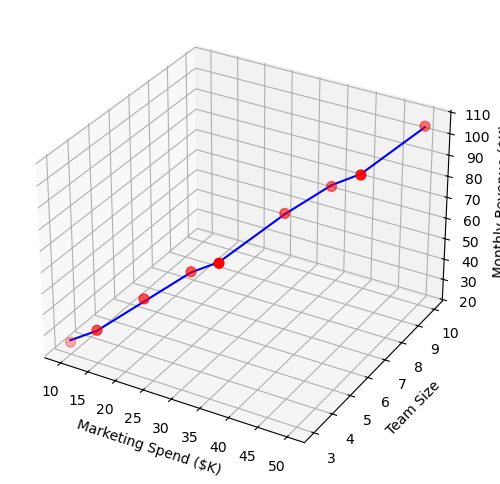

In [25]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["marketing_spend"], df["team_size"], df["monthly_revenue"], color="red", s=50)

ax.set_xlabel("Marketing Spend ($K)")
ax.set_ylabel("Team Size")
ax.set_zlabel("Monthly Revenue ($K)")

ax.plot(df["marketing_spend"],df["team_size"],reg.predict(df[["marketing_spend","team_size"]]),color="blue",label="Regression Trend")
plt.show()
